In [7]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [8]:
import zipfile
import pandas as pd

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as z:
    z.extractall("aqi_data")

    df = pd.read_csv("aqi_data/INDIA_AQI_COMPLETE_20251126.csv")

    print("Dataset loaded!")
    print("Rows and columns:", df.shape)

    display(df.head())

Dataset loaded!
Rows and columns: (842160, 71)


,City,State,Latitude,Longitude,Datetime,Year,Month,Day,Hour,Day_of_Week,...,US_AQI_CO,EU_AQI,EU_AQI_PM25,EU_AQI_PM10,AQI_Category,PM25_Category_India,Temp_Inversion,Inversion_Strength_C,Festival_Period,Crop_Burning_Season
0,Agartala,Tripura,23.8315,91.2868,2022-08-05 00:00:00,2022,8,5,0,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
1,Agartala,Tripura,23.8315,91.2868,2022-08-05 01:00:00,2022,8,5,1,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
2,Agartala,Tripura,23.8315,91.2868,2022-08-05 02:00:00,2022,8,5,2,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
3,Agartala,Tripura,23.8315,91.2868,2022-08-05 03:00:00,2022,8,5,3,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
4,Agartala,Tripura,23.8315,91.2868,2022-08-05 04:00:00,2022,8,5,4,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0


In [9]:
print("All columns:")
for i, col in enumerate(df.columns, 1):
    print(i, col)

All columns:
1 City
2 State
3 Latitude
4 Longitude
5 Datetime
6 Year
7 Month
8 Day
9 Hour
10 Day_of_Week
11 Day_Name
12 Week_of_Year
13 Is_Weekend
14 Quarter
15 Season
16 Time_of_Day
17 Temp_2m_C
18 Temp_80m_C
19 Temp_120m_C
20 Temp_180m_C
21 Humidity_Percent
22 Dew_Point_C
23 Humidity_Category
24 Wind_Speed_10m_kmh
25 Wind_Speed_80m_kmh
26 Wind_Speed_120m_kmh
27 Wind_Dir_10m
28 Wind_Gusts_kmh
29 Wind_Category
30 Wind_Stagnation
31 Precipitation_mm
32 Rain_mm
33 Is_Raining
34 Heavy_Rain
35 Pressure_MSL_hPa
36 Surface_Pressure_hPa
37 Solar_Radiation_Wm2
38 Direct_Radiation_Wm2
39 Diffuse_Radiation_Wm2
40 UV_Index
41 Cloud_Cover_Percent
42 Cloud_Low_Percent
43 Cloud_Mid_Percent
44 Cloud_High_Percent
45 Is_Daytime
46 Sunshine_Seconds
47 PM2_5_ugm3
48 PM10_ugm3
49 PM_Ratio
50 CO_ugm3
51 NO2_ugm3
52 SO2_ugm3
53 O3_ugm3
54 Dust_ugm3
55 NH3_ugm3
56 AOD
57 US_AQI
58 US_AQI_PM25
59 US_AQI_PM10
60 US_AQI_NO2
61 US_AQI_O3
62 US_AQI_CO
63 EU_AQI
64 EU_AQI_PM25
65 EU_AQI_PM10
66 AQI_Category
67 PM2

In [10]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nMissing values:")
display(df.isnull().sum())

Number of rows: 842160
Number of columns: 71

Missing values:


,0
City,0
State,0
Latitude,0
Longitude,0
Datetime,0
...,...
PM25_Category_India,2
Temp_Inversion,0
Inversion_Strength_C,842160
Festival_Period,0


In [11]:
# Data Quality Check

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
display(df.dtypes)

Dataset Shape: (842160, 71)

Missing Values:


,0
City,0
State,0
Latitude,0
Longitude,0
Datetime,0
...,...
PM25_Category_India,2
Temp_Inversion,0
Inversion_Strength_C,842160
Festival_Period,0



Duplicate Rows: 0

Data Types:


,0
City,object
State,object
Latitude,float64
Longitude,float64
Datetime,object
...,...
PM25_Category_India,object
Temp_Inversion,int64
Inversion_Strength_C,float64
Festival_Period,int64


In [12]:
# Statistical summary

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Latitude,842160.0,23.129041,5.543478,8.5241,20.2961,23.8315,26.9124,31.1048
Longitude,842160.0,82.769207,6.937205,72.5714,77.1734,80.9462,88.6065,94.1086
Year,842160.0,2023.724793,0.995593,2022.0000,2023.0000,2024.0000,2025.0000,2025.0000
Month,842160.0,6.801653,3.411504,1.0000,4.0000,7.0000,10.0000,12.0000
Day,842160.0,15.736364,8.767003,1.0000,8.0000,16.0000,23.0000,31.0000
...,...,...,...,...,...,...,...,...
EU_AQI_PM10,842015.0,48.424171,38.903157,1.0000,23.0000,40.0000,67.0000,1179.0000
Temp_Inversion,842160.0,0.000000,0.000000,0.0000,0.0000,0.0000,0.0000,0.0000
Inversion_Strength_C,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Festival_Period,842160.0,0.105785,0.307563,0.0000,0.0000,0.0000,0.0000,1.0000


In [13]:
print(df.columns.tolist())

['City', 'State', 'Latitude', 'Longitude', 'Datetime', 'Year', 'Month', 'Day', 'Hour', 'Day_of_Week', 'Day_Name', 'Week_of_Year', 'Is_Weekend', 'Quarter', 'Season', 'Time_of_Day', 'Temp_2m_C', 'Temp_80m_C', 'Temp_120m_C', 'Temp_180m_C', 'Humidity_Percent', 'Dew_Point_C', 'Humidity_Category', 'Wind_Speed_10m_kmh', 'Wind_Speed_80m_kmh', 'Wind_Speed_120m_kmh', 'Wind_Dir_10m', 'Wind_Gusts_kmh', 'Wind_Category', 'Wind_Stagnation', 'Precipitation_mm', 'Rain_mm', 'Is_Raining', 'Heavy_Rain', 'Pressure_MSL_hPa', 'Surface_Pressure_hPa', 'Solar_Radiation_Wm2', 'Direct_Radiation_Wm2', 'Diffuse_Radiation_Wm2', 'UV_Index', 'Cloud_Cover_Percent', 'Cloud_Low_Percent', 'Cloud_Mid_Percent', 'Cloud_High_Percent', 'Is_Daytime', 'Sunshine_Seconds', 'PM2_5_ugm3', 'PM10_ugm3', 'PM_Ratio', 'CO_ugm3', 'NO2_ugm3', 'SO2_ugm3', 'O3_ugm3', 'Dust_ugm3', 'NH3_ugm3', 'AOD', 'US_AQI', 'US_AQI_PM25', 'US_AQI_PM10', 'US_AQI_NO2', 'US_AQI_O3', 'US_AQI_CO', 'EU_AQI', 'EU_AQI_PM25', 'EU_AQI_PM10', 'AQI_Category', 'PM25_Cat

In [16]:
print("All dataset columns:")
for i, col in enumerate(df.columns, 1):
    print(i, col)

All dataset columns:
1 City
2 State
3 Latitude
4 Longitude
5 Datetime
6 Year
7 Month
8 Day
9 Hour
10 Day_of_Week
11 Day_Name
12 Week_of_Year
13 Is_Weekend
14 Quarter
15 Season
16 Time_of_Day
17 Temp_2m_C
18 Temp_80m_C
19 Temp_120m_C
20 Temp_180m_C
21 Humidity_Percent
22 Dew_Point_C
23 Humidity_Category
24 Wind_Speed_10m_kmh
25 Wind_Speed_80m_kmh
26 Wind_Speed_120m_kmh
27 Wind_Dir_10m
28 Wind_Gusts_kmh
29 Wind_Category
30 Wind_Stagnation
31 Precipitation_mm
32 Rain_mm
33 Is_Raining
34 Heavy_Rain
35 Pressure_MSL_hPa
36 Surface_Pressure_hPa
37 Solar_Radiation_Wm2
38 Direct_Radiation_Wm2
39 Diffuse_Radiation_Wm2
40 UV_Index
41 Cloud_Cover_Percent
42 Cloud_Low_Percent
43 Cloud_Mid_Percent
44 Cloud_High_Percent
45 Is_Daytime
46 Sunshine_Seconds
47 PM2_5_ugm3
48 PM10_ugm3
49 PM_Ratio
50 CO_ugm3
51 NO2_ugm3
52 SO2_ugm3
53 O3_ugm3
54 Dust_ugm3
55 NH3_ugm3
56 AOD
57 US_AQI
58 US_AQI_PM25
59 US_AQI_PM10
60 US_AQI_NO2
61 US_AQI_O3
62 US_AQI_CO
63 EU_AQI
64 EU_AQI_PM25
65 EU_AQI_PM10
66 AQI_Categor

In [18]:
columns_15 = [
      'City',
          'State',
              'Datetime',
                  'Year',
                      'Month',
                          'Season',
                              'PM2_5_ugm3',
                                  'PM10_ugm3',
                                      'CO_ugm3',
                                          'NO2_ugm3',
                                              'SO2_ugm3',
                                                  'O3_ugm3',
                                                      'NH3_ugm3',
                                                          'US_AQI',
                                                              'AQI_Category'
                                                              ]

df_15 = df[columns_15].copy()

print("15-column dataset shape:", df_15.shape)

display(df_15.head())


15-column dataset shape: (842160, 15)


,City,State,Datetime,Year,Month,Season,PM2_5_ugm3,PM10_ugm3,CO_ugm3,NO2_ugm3,SO2_ugm3,O3_ugm3,NH3_ugm3,US_AQI,AQI_Category
0,Agartala,Tripura,2022-08-05 00:00:00,2022,8,Monsoon,14.8,21.5,197.0,21.8,2.7,32.0,NaN,NaN,NaN
1,Agartala,Tripura,2022-08-05 01:00:00,2022,8,Monsoon,15.7,22.8,196.0,18.5,3.0,33.0,NaN,NaN,NaN
2,Agartala,Tripura,2022-08-05 02:00:00,2022,8,Monsoon,16.3,23.5,196.0,15.1,3.3,34.0,NaN,NaN,NaN
3,Agartala,Tripura,2022-08-05 03:00:00,2022,8,Monsoon,17.6,25.4,197.0,14.1,3.3,32.0,NaN,NaN,NaN
4,Agartala,Tripura,2022-08-05 04:00:00,2022,8,Monsoon,18.2,26.2,199.0,13.9,3.2,30.0,NaN,NaN,NaN


In [19]:
print("Missing values before cleaning:")

missing_before = df_15.isnull().sum()

display(missing_before)

Missing values before cleaning:


,0
City,0
State,0
Datetime,0
Year,0
Month,0
Season,0
PM2_5_ugm3,0
PM10_ugm3,0
CO_ugm3,0
NO2_ugm3,0


In [20]:
print("Duplicate rows before cleaning:", df_15.duplicated().sum())

Duplicate rows before cleaning: 0


In [22]:
# Create a copy for cleaning
clean_df = df_15.copy()

# Convert Datetime
clean_df['Datetime'] = pd.to_datetime(
    clean_df['Datetime'],
        errors='coerce'
        )

        # Numerical columns
numeric_cols = [
            'PM2_5_ugm3',
                'PM10_ugm3',
                    'CO_ugm3',
                        'NO2_ugm3',
                            'SO2_ugm3',
                                'O3_ugm3',
                                    'NH3_ugm3',
                                        'US_AQI'
                                        ]

                                        # Fill numerical missing values with median
for col in numeric_cols:
                                            clean_df[col] = clean_df[col].fillna(clean_df[col].median())

                                            # Categorical columns
                                            categorical_cols = [
                                                'City',
                                                    'State',
                                                        'Year',
                                                            'Month',
                                                                'Season',
                                                                    'AQI_Category'
                                                                    ]

                                                                    # Fill categorical missing values with mode
for col in categorical_cols:
                                                                        if clean_df[col].isnull().sum() > 0:
                                                                                clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])

                                                                                print("Cleaning completed!")

Cleaning completed!


In [23]:
print("Missing values AFTER cleaning:")

display(clean_df.isnull().sum())

Missing values AFTER cleaning:


,0
City,0
State,0
Datetime,0
Year,0
Month,0
Season,0
PM2_5_ugm3,0
PM10_ugm3,0
CO_ugm3,0
NO2_ugm3,0


In [24]:
# Remove the completely empty NH3 column
clean_df = df_15.drop(columns=['NH3_ugm3']).copy()

# Add a useful AQI-related column
clean_df['PM25_Category_India'] = df['PM25_Category_India']

# Convert datetime
clean_df['Datetime'] = pd.to_datetime(
    clean_df['Datetime'],
        errors='coerce'
        )

        # Numerical columns
numeric_cols = [
            'PM2_5_ugm3',
                'PM10_ugm3',
                    'CO_ugm3',
                        'NO2_ugm3',
                            'SO2_ugm3',
                                'O3_ugm3',
                                    'US_AQI'
                                    ]

                                    # Fill missing numerical values with median
for col in numeric_cols:
                                        clean_df[col] = clean_df[col].fillna(clean_df[col].median())

                                        # Categorical columns
                                        categorical_cols = [
                                            'City',
                                                'State',
                                                    'Year',
                                                        'Month',
                                                            'Season',
                                                                'AQI_Category',
                                                                    'PM25_Category_India'
                                                                    ]

for col in categorical_cols:
                                                                        if clean_df[col].isnull().sum() > 0:
                                                                                clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])

                                                                                print("Cleaned dataset shape:", clean_df.shape)

Cleaned dataset shape: (842160, 15)
Cleaned dataset shape: (842160, 15)


In [25]:
print("Missing values BEFORE cleaning:")
display(df_15.isnull().sum())

print("\nMissing values AFTER cleaning:")
display(clean_df.isnull().sum())

Missing values BEFORE cleaning:


,0
City,0
State,0
Datetime,0
Year,0
Month,0
Season,0
PM2_5_ugm3,0
PM10_ugm3,0
CO_ugm3,0
NO2_ugm3,0



Missing values AFTER cleaning:


,0
City,0
State,0
Datetime,0
Year,0
Month,0
Season,0
PM2_5_ugm3,0
PM10_ugm3,0
CO_ugm3,0
NO2_ugm3,0


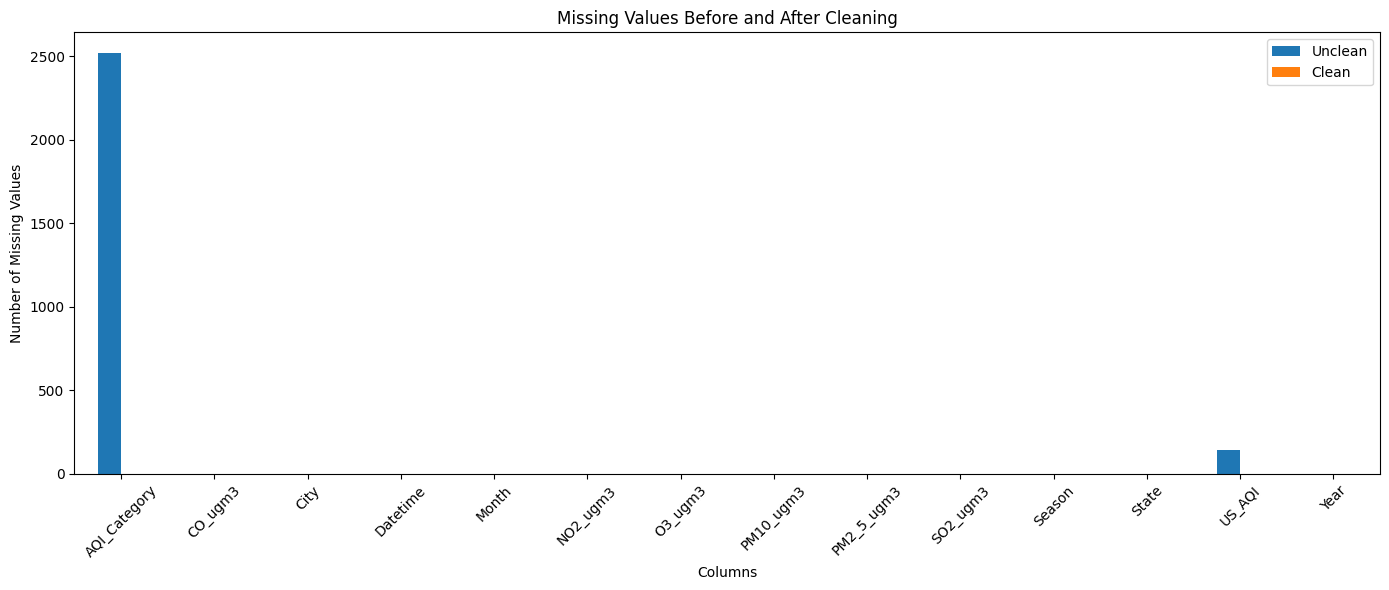

In [28]:
# Compare missing values excluding completely empty columns

before = df_15.isnull().sum()
after = clean_df.isnull().sum()

comparison = pd.DataFrame({
    'Unclean': before,
        'Clean': after
        })

        # Remove columns that had 100% missing values
comparison = comparison[comparison['Unclean'] < len(df_15)]

comparison.plot(
            kind='bar',
                figsize=(14, 6)
                )

plt.title('Missing Values Before and After Cleaning')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

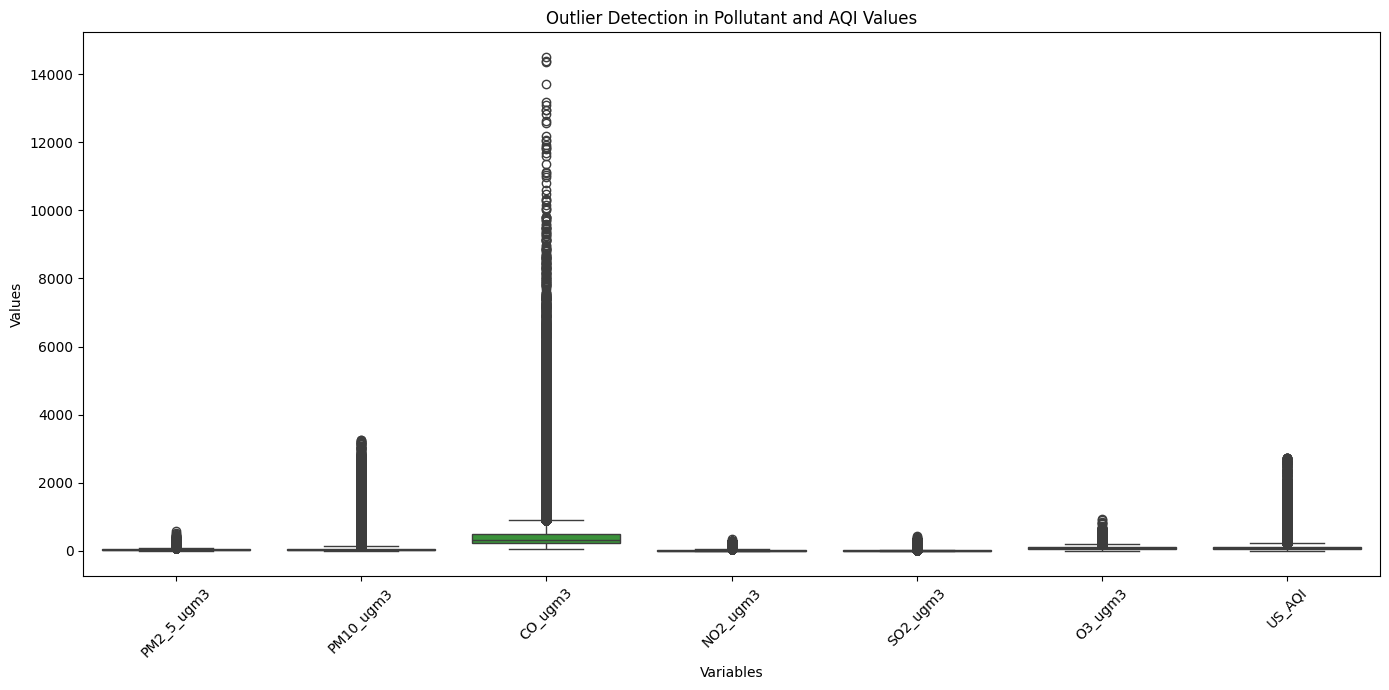

In [29]:
# Check outliers using box plots

numeric_cols = [
    'PM2_5_ugm3',
        'PM10_ugm3',
            'CO_ugm3',
                'NO2_ugm3',
                    'SO2_ugm3',
                        'O3_ugm3',
                            'US_AQI'
                            ]

plt.figure(figsize=(14, 7))

sns.boxplot(data=df_15[numeric_cols])

plt.title("Outlier Detection in Pollutant and AQI Values")
plt.xlabel("Variables")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# Step 9: Treat outliers using IQR method

clean_outlier_df = clean_df.copy()

numeric_cols = [
    'PM2_5_ugm3',
        'PM10_ugm3',
            'CO_ugm3',
                'NO2_ugm3',
                    'SO2_ugm3',
                        'O3_ugm3',
                            'US_AQI'
                            ]

for col in numeric_cols:
                                Q1 = clean_outlier_df[col].quantile(0.25)
Q3 = clean_outlier_df[col].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

clean_outlier_df[col] = clean_outlier_df[col].clip(
                                                            lower=lower_limit,
                                                                    upper=upper_limit
                                                                        )

print("Outlier treatment completed!")

Outlier treatment completed!


In [31]:
# Final cleaned dataset
final_df = clean_outlier_df.copy()

print("Final dataset shape:", final_df.shape)
display(final_df.head())

Final dataset shape: (842160, 15)


,City,State,Datetime,Year,Month,Season,PM2_5_ugm3,PM10_ugm3,CO_ugm3,NO2_ugm3,SO2_ugm3,O3_ugm3,US_AQI,AQI_Category,PM25_Category_India
0,Agartala,Tripura,2022-08-05 00:00:00,2022,8,Monsoon,14.8,21.5,197.0,21.8,2.7,32.0,84.0,Moderate,Good
1,Agartala,Tripura,2022-08-05 01:00:00,2022,8,Monsoon,15.7,22.8,196.0,18.5,3.0,33.0,84.0,Moderate,Good
2,Agartala,Tripura,2022-08-05 02:00:00,2022,8,Monsoon,16.3,23.5,196.0,15.1,3.3,34.0,84.0,Moderate,Good
3,Agartala,Tripura,2022-08-05 03:00:00,2022,8,Monsoon,17.6,25.4,197.0,14.1,3.3,32.0,84.0,Moderate,Good
4,Agartala,Tripura,2022-08-05 04:00:00,2022,8,Monsoon,18.2,26.2,199.0,13.9,3.2,30.0,84.0,Moderate,Good


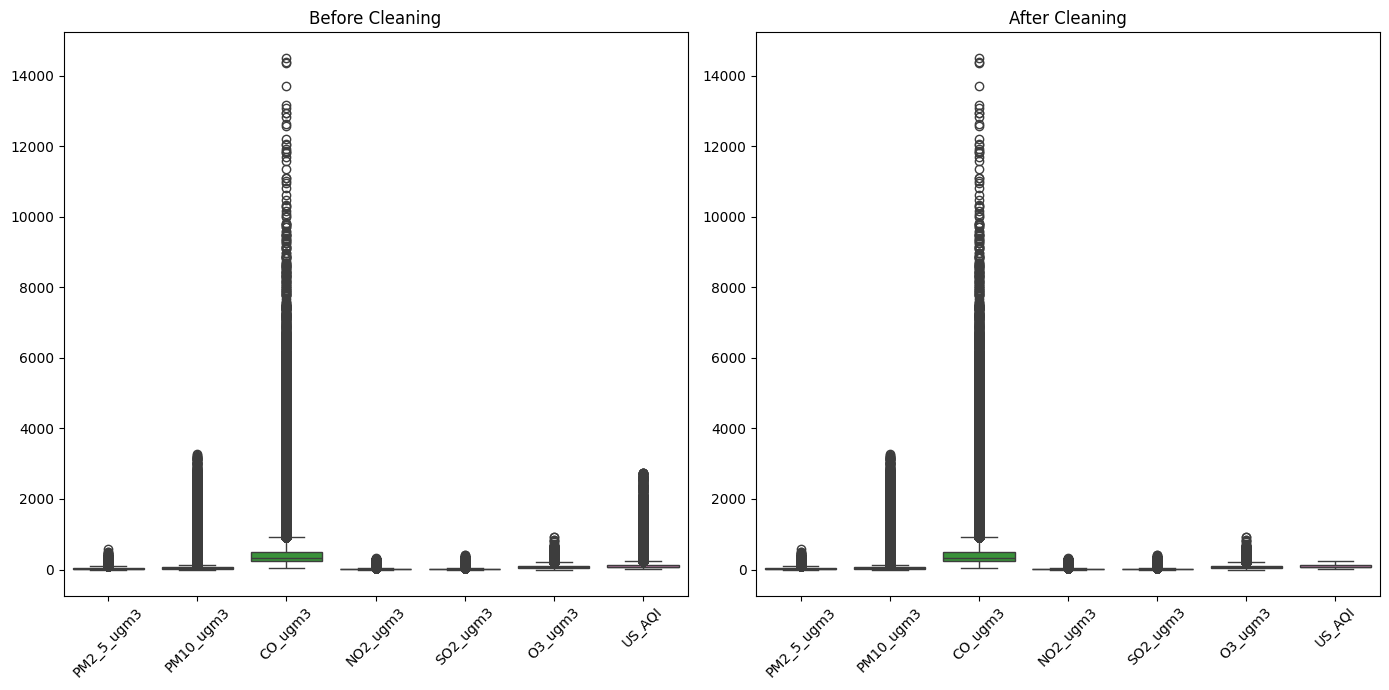

In [32]:
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
sns.boxplot(data=df_15[numeric_cols])
plt.title("Before Cleaning")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(data=final_df[numeric_cols])
plt.title("After Cleaning")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [33]:
# Statistical comparison: Unclean vs Clean

comparison_stats = pd.DataFrame({
    'Unclean Mean': df_15[numeric_cols].mean(),
        'Clean Mean': final_df[numeric_cols].mean(),
            'Unclean Median': df_15[numeric_cols].median(),
                'Clean Median': final_df[numeric_cols].median()
                })

display(comparison_stats)

,Unclean Mean,Clean Mean,Unclean Median,Clean Median
PM2_5_ugm3,34.739642,34.739642,25.9,25.9
PM10_ugm3,56.257083,56.257083,39.0,39.0
CO_ugm3,450.891150,450.891150,333.0,333.0
NO2_ugm3,16.132833,16.132833,9.0,9.0
SO2_ugm3,13.599054,13.599054,6.9,6.9
O3_ugm3,80.479350,80.479350,73.0,73.0
US_AQI,96.804419,94.336904,84.0,84.0


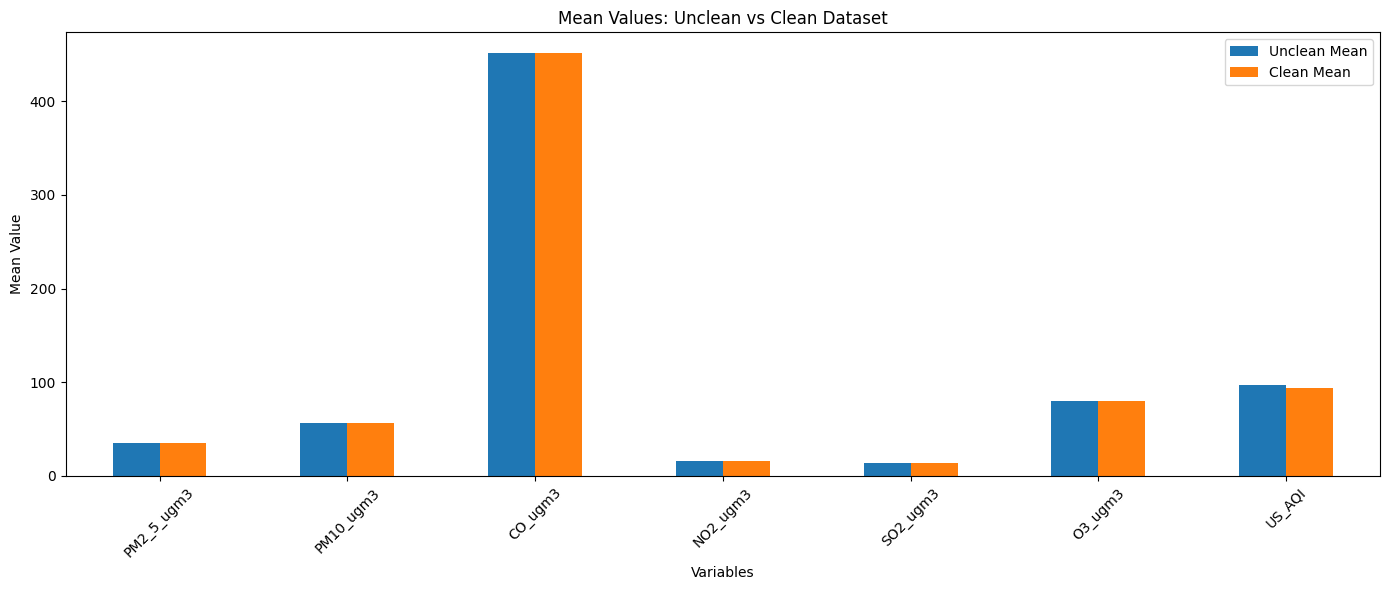

In [34]:
comparison_stats[['Unclean Mean', 'Clean Mean']].plot(
      kind='bar',
          figsize=(14, 6)
          )

plt.title("Mean Values: Unclean vs Clean Dataset")
plt.xlabel("Variables")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [35]:
# Final data quality check

print("Final Dataset Shape:", final_df.shape)

print("\nMissing Values:")
display(final_df.isnull().sum())

print("\nDuplicate Rows:", final_df.duplicated().sum())

print("\nData Types:")
display(final_df.dtypes)

Final Dataset Shape: (842160, 15)

Missing Values:


,0
City,0
State,0
Datetime,0
Year,0
Month,0
Season,0
PM2_5_ugm3,0
PM10_ugm3,0
CO_ugm3,0
NO2_ugm3,0



Duplicate Rows: 0

Data Types:


,0
City,object
State,object
Datetime,datetime64[ns]
Year,int64
Month,int64
Season,object
PM2_5_ugm3,float64
PM10_ugm3,float64
CO_ugm3,float64
NO2_ugm3,float64


In [36]:
print("Final Statistical Summary:")
display(final_df.describe().T)

Final Statistical Summary:


,count,mean,min,25%,50%,75%,max,std
Datetime,842160,2024-03-31 23:30:00,2022-08-05 00:00:00,2023-06-03 11:45:00,2024-03-31 23:30:00,2025-01-28 11:15:00,2025-11-26 23:00:00,NaN
Year,842160.0,2023.724793,2022.0,2023.0,2024.0,2025.0,2025.0,0.995593
Month,842160.0,6.801653,1.0,4.0,7.0,10.0,12.0,3.411504
PM2_5_ugm3,842160.0,34.739642,0.1,14.7,25.9,44.2,581.1,30.843496
PM10_ugm3,842160.0,56.257083,0.1,21.5,39.0,66.4,3263.4,83.837033
CO_ugm3,842160.0,450.89115,56.0,235.0,333.0,508.0,14504.0,434.552149
NO2_ugm3,842160.0,16.132833,-0.2,3.7,9.0,19.9,336.0,20.813405
SO2_ugm3,842160.0,13.599054,-0.2,2.8,6.9,15.8,424.6,20.61702
O3_ugm3,842160.0,80.47935,-11.0,47.0,73.0,108.0,930.0,46.196459
US_AQI,842160.0,94.336904,9.0,59.0,84.0,128.0,231.5,45.991973


In [38]:
# Create and save the final cleaned dataset

final_df.to_csv("AQI_Cleaned.csv", index=False)

print("AQI_Cleaned.csv created successfully!")
print("Shape:", final_df.shape)

AQI_Cleaned.csv created successfully!
Shape: (842160, 15)


In [39]:
from google.colab import files

files.download("AQI_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

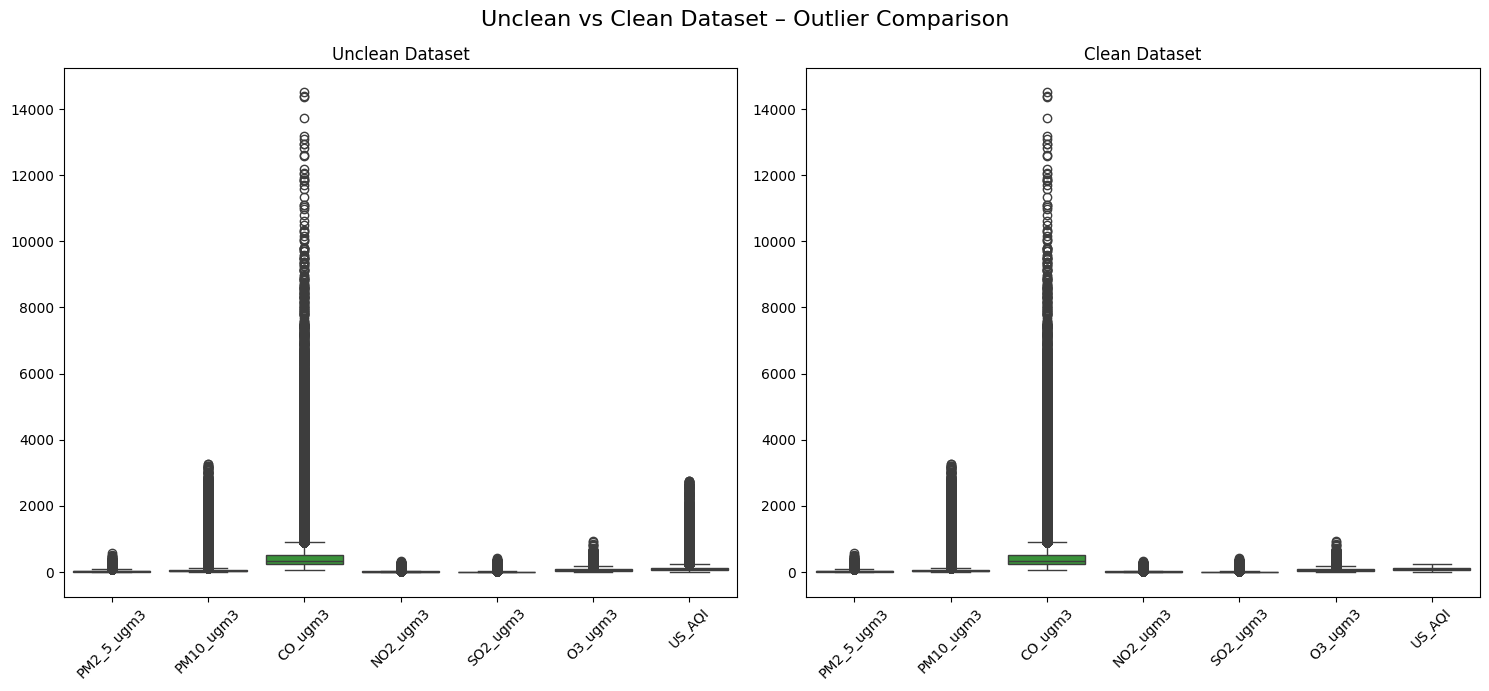

In [41]:
# FINAL COMPARISON GRAPH
# Unclean vs Clean Dataset

numeric_cols = [
    'PM2_5_ugm3',
        'PM10_ugm3',
            'CO_ugm3',
                'NO2_ugm3',
                    'SO2_ugm3',
                        'O3_ugm3',
                            'US_AQI'
                            ]

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
sns.boxplot(data=df_15[numeric_cols])
plt.title("Unclean Dataset")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(data=final_df[numeric_cols])
plt.title("Clean Dataset")
plt.xticks(rotation=45)

plt.suptitle("Unclean vs Clean Dataset – Outlier Comparison", fontsize=16)

plt.tight_layout()
plt.show()